# Fairness — formal test, Fairlearn metrics, FPDP, equivalence test

Independence/Separation/Sufficiency, standard Fairlearn metrics, FPDP diagnosis, and a
fairness equivalence (TOST) test, for whichever models have a `models/<name>_model.py` file
so far.

`test_independence`/`test_separation`/`test_sufficiency` are our own chi-square /
Fisher's-method implementations of each definition's null hypothesis, not a specific
published test statistic — treat pass/fail as directionally right, and swap in a more
specific test if the write-up needs one.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("../..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import tost_proportions_2indep, confint_proportions_2indep

import common_metrics as cm

NB_OUTPUT_DIR = cm.OUTPUT_DIR / "fairness"
NB_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    from fairlearn.metrics import (
        MetricFrame, selection_rate, true_positive_rate, false_positive_rate,
        demographic_parity_ratio, equalized_odds_difference,
    )
    HAS_FAIRLEARN = True
except ImportError:
    HAS_FAIRLEARN = False
    print("fairlearn not installed — pip install fairlearn, then re-run this cell")

cm.report_status()

Ready:   ['xgboost', 'logreg', 'tabpfn']
Waiting: (none — all models in)


## Load data

In [2]:
train_df = cm.load_split("train")
test_df = cm.load_split("test")

X_train, y_train = cm.get_X_y(train_df)
X_test, y_test = cm.get_X_y(test_df)

print(f"train: {X_train.shape}, test: git {X_test.shape}")

train: (6399841, 31), test: git (1371203, 31)


## 1. Formal fairness test — Independence, Separation, Sufficiency

Independence: prediction unrelated to the protected attribute (statistical parity).
Separation: prediction independent of the attribute *given the true outcome* (equal
TPR/FPR across groups). Sufficiency: true outcome independent of the attribute
*given the score* (calibration holds equally across groups).

In [3]:
def test_independence(y_pred, group):
    table = pd.crosstab(group, y_pred)
    chi2, p, dof, expected = stats.chi2_contingency(table)
    return {"statistic": chi2, "p_value": p}


def test_separation(y_pred, y_true, group):
    p_values = []
    for outcome in [0, 1]:
        mask = y_true == outcome
        if mask.sum() == 0:
            continue
        table = pd.crosstab(group[mask], y_pred[mask])
        if table.shape[0] < 2 or table.shape[1] < 2:
            continue
        chi2, p, dof, expected = stats.chi2_contingency(table)
        p_values.append(p)
    if not p_values:
        return {"statistic": np.nan, "p_value": np.nan}
    combined_stat, combined_p = stats.combine_pvalues(p_values, method="fisher")
    return {"statistic": combined_stat, "p_value": combined_p}


def test_sufficiency(y_pred_proba, y_true, group, n_bins=10):
    try:
        bins = pd.qcut(y_pred_proba, q=n_bins, duplicates="drop")
    except ValueError:
        return {"statistic": np.nan, "p_value": np.nan}
    table = pd.crosstab([bins, group], y_true)
    try:
        chi2, p, dof, expected = stats.chi2_contingency(table)
    except ValueError:
        return {"statistic": np.nan, "p_value": np.nan}
    return {"statistic": chi2, "p_value": p}


def fairness_test(audit, group_col):
    return {
        "independence": test_independence(audit["y_pred"], audit[group_col]),
        "separation": test_separation(audit["y_pred"], audit["y_true"], audit[group_col]),
        "sufficiency": test_sufficiency(audit["y_pred_proba"], audit["y_true"], audit[group_col]),
    }

## 1b. Conditional statistical parity

Plain Independence checks whether approval rates differ by group overall, which invites the
objection "that's just different risk profiles, not discrimination." This answers it
directly: bin applicants into similar-risk bands (by DTI or LTV) first, then check whether
approval rates still differ by group *within* a band. Same chi-square-per-stratum +
Fisher's-method structure as `test_separation`, conditioning on risk band instead of outcome.

In [4]:
RISK_SCORE_COLS = [f for f in ["debt_to_income_ratio", "combined_loan_to_value_ratio"] if f in cm.FEATURES]

def test_conditional_statistical_parity(y_pred, group, risk_score, n_bins=5):
    try:
        bins = pd.qcut(risk_score, q=n_bins, duplicates="drop")
    except ValueError:
        return {"statistic": np.nan, "p_value": np.nan}
    p_values = []
    for b in bins.cat.categories:
        mask = bins == b
        if mask.sum() == 0:
            continue
        table = pd.crosstab(group[mask], y_pred[mask])
        if table.shape[0] < 2 or table.shape[1] < 2:
            continue
        chi2, p, dof, expected = stats.chi2_contingency(table)
        p_values.append(p)
    if not p_values:
        return {"statistic": np.nan, "p_value": np.nan}
    combined_stat, combined_p = stats.combine_pvalues(p_values, method="fisher")
    return {"statistic": combined_stat, "p_value": combined_p}

## 2. Fairlearn standard metrics — and why the pair comparison is the primary one

Fairlearn's `demographic_parity_ratio` is the lowest group approval rate divided by the highest,
across *every* category of the attribute — it's the same number as an "all-groups" disparate
impact ratio. On HMDA that's misleading as a headline: the categories include "Joint",
"... Not Available", and "Free Form Text Only" (a few hundred applicants for race), so the
min/max ratio gets set by whichever tiny or non-demographic category happens to be extreme,
not by the comparison the 4/5ths rule is actually about. Same problem for
`equalized_odds_difference`, which is also a max over every pair of categories.

`pair_metrics` computes both on the named protected-vs-reference pair from `FAIRNESS_PAIRS`
(e.g. Female vs Male) — that's the primary number. The all-groups versions are kept as a
secondary column so nothing is hidden.

In [5]:
def compute_fairlearn_metrics(audit, group_col):
    if not HAS_FAIRLEARN:
        return None
    mf = MetricFrame(
        metrics={"selection_rate": selection_rate, "tpr": true_positive_rate, "fpr": false_positive_rate},
        y_true=audit["y_true"], y_pred=audit["y_pred"], sensitive_features=audit[group_col],
    )
    return {
        "by_group": mf.by_group,
        "demographic_parity_ratio": demographic_parity_ratio(audit["y_true"], audit["y_pred"], sensitive_features=audit[group_col]),
        "equalized_odds_difference": equalized_odds_difference(audit["y_true"], audit["y_pred"], sensitive_features=audit[group_col]),
    }


def pair_metrics(by_group, pair):
    """Disparate impact and equalized odds for one protected-vs-reference pair, from by_group."""
    if pair is None or pair[0] not in by_group.index or pair[1] not in by_group.index:
        return None
    protected, reference = by_group.loc[pair[0]], by_group.loc[pair[1]]
    tpr_gap = protected["tpr"] - reference["tpr"]
    fpr_gap = protected["fpr"] - reference["fpr"]
    return {
        "dir": protected["selection_rate"] / reference["selection_rate"],
        "tpr_gap": tpr_gap,
        "fpr_gap": fpr_gap,
        "eod": max(abs(tpr_gap), abs(fpr_gap)),
    }

## 3. Fairness Partial Dependence Plot (FPDP) — candidate-variable diagnosis

Only meaningful for a (model, attribute) pair that already rejected in step 1 — this
answers *why*, not *whether*. Swept over `debt_to_income_ratio`/`combined_loan_to_value_ratio`
(the tract-level and MSA-income variables that could otherwise be prime candidates are
excluded from `X` entirely — see `common_metrics.PROTECTED_COLS`). Plotted in the charts
section below, all models overlaid on one axis.

In [6]:
def fairness_pdp(model, module, X, feature, group_series, group_a, group_b, n_points=20):
    disparities = []
    grid = np.linspace(X[feature].quantile(0.05), X[feature].quantile(0.95), n_points)
    for val in grid:
        X_mod = X.copy()
        X_mod[feature] = val
        preds = module.predict_proba(model, X_mod)[:, 1]
        gap = preds[(group_series == group_a).values].mean() - preds[(group_series == group_b).values].mean()
        disparities.append((val, gap))
    return disparities

## 4. Fairness Equivalence test (TOST) — primary for this dataset

With ~1.37M test rows, step 1's classical test will reject on almost any nonzero gap, so
it's not that informative here. TOST flips the null: `H0: |θ| > δ` (unfair) vs.
`H1: |θ| < δ` (fair within tolerance `δ`), via `statsmodels.tost_proportions_2indep`.

TOST at level α rejects exactly when the (1 − 2α) confidence interval of θ sits entirely inside
(−δ, δ) — so with α = 0.05 the chart below shows the 90% CI against the ±δ band. Both the test
and the interval use the same method (`TOST_METHOD`), so the picture and the p-value can't
disagree.

In [7]:
TOST_METHOD = "score"


def tost_two_proportions(count_a, nobs_a, count_b, nobs_b, delta, alpha=0.05):
    result = tost_proportions_2indep(count_a, nobs_a, count_b, nobs_b, low=-delta, upp=delta, compare="diff", method=TOST_METHOD)
    ci_low, ci_high = confint_proportions_2indep(count_a, nobs_a, count_b, nobs_b, compare="diff", alpha=2 * alpha, method=TOST_METHOD)
    return {
        "theta_hat": count_a / nobs_a - count_b / nobs_b,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "tost_p": result.pvalue,
        "equivalent": result.pvalue < alpha,
    }


DELTA = 0.02  # team-agreed tolerance — TODO(team): confirm this value

# (protected, reference). TODO(team): confirm these are the right comparison pairs;
# applicant_age and co_applicant_age are banded (e.g. "25-34"), so pick two specific bands
# before running the equivalence test / pair metrics on either.
FAIRNESS_PAIRS = {
    "derived_sex": ("Female", "Male"),
    "derived_ethnicity": ("Hispanic or Latino", "Not Hispanic or Latino"),
    "derived_race": ("Black or African American", "White"),
    "applicant_age": None,
    "co_applicant_age": None,
}

## 5. Group curves — calibration (Sufficiency) and conditional parity, by group

Computed inside the pipeline loop (and checkpointed like everything else), plotted in the charts
section. Curves only draw the named pair when an attribute has one; for the age attributes
(no pair yet) they draw every band with at least `MIN_CURVE_GROUP_N` test applicants, so a line
isn't just noise from a handful of rows. Group sizes come from the full test set.

In [8]:
AGE_ORDER = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]
MIN_CURVE_GROUP_N = 1000
TEST_GROUP_COUNTS = {col: test_df[col].value_counts() for col in cm.AUDIT_COLS}


def order_groups(groups, col):
    """Age bands in natural order (not "<25" and ">74" sorted last as text); everything else
    alphabetical, so a group sits in the same position in every model's panel."""
    groups = [g for g in groups if pd.notna(g)]
    if col in ("applicant_age", "co_applicant_age"):
        return [g for g in AGE_ORDER if g in groups] + sorted((g for g in groups if g not in AGE_ORDER), key=str)
    return sorted(groups, key=str)


def curve_groups(col):
    pair = FAIRNESS_PAIRS.get(col)
    if pair:
        return list(pair)
    counts = TEST_GROUP_COUNTS[col]
    return order_groups([g for g, n in counts.items() if n >= MIN_CURVE_GROUP_N], col)


def calibration_by_group(audit, col, groups, n_bins=10):
    """Mean predicted approval probability vs. observed approval rate, per score decile, per
    group — the visual form of Sufficiency (a group whose curve sits below the others is
    over-scored relative to its actual outcomes)."""
    edges = np.unique(np.quantile(audit["y_pred_proba"], np.linspace(0, 1, n_bins + 1)))
    bins = pd.cut(audit["y_pred_proba"], edges, include_lowest=True)
    curves = {}
    for g in groups:
        sub = audit[audit[col] == g]
        grouped = sub.groupby(bins.loc[sub.index], observed=True)
        curves[g] = pd.DataFrame({
            "mean_predicted": grouped["y_pred_proba"].mean(),
            "observed_rate": grouped["y_true"].mean(),
            "n": grouped.size(),
        })
    return curves


def conditional_parity_by_group(audit, col, groups, n_bins=5):
    """Approval rate per risk-score quintile, per group — the visual form of conditional
    statistical parity (a gap that persists within every band isn't explained by risk)."""
    in_groups = audit[audit[col].isin(groups)]
    curves = {}
    for risk_col in RISK_SCORE_COLS:
        bands = pd.qcut(audit[risk_col], q=n_bins, duplicates="drop")
        table = in_groups.groupby([bands.loc[in_groups.index], in_groups[col]], observed=True)["y_pred"].mean()
        curves[risk_col] = table.unstack(col).reindex(columns=groups)
    return curves

## Run the fairness pipeline across available models

logreg and TabPFN already export their test-set scores from their own training notebooks
(`get_precomputed_predictions`), so this reads those instead of re-running inference. XGBoost
has no such export, so it falls back to `get_or_fit_model` + one live `predict_proba` pass —
cheap regardless, since XGBoost isn't the slow one; avoiding TabPFN's CPU cost is the actual
point here. Every attribute's tests go through `run_step`, so one failing doesn't lose the
rest. Nothing is plotted in this loop — the charts section below renders everything from
`fairness_results`, so restyling a chart never re-runs a test.

**Checkpointing**: same mechanism as the other two notebooks — each attribute's results are
checkpointed under `outputs/evaluation/fairness/checkpoints/<model>/<attribute>/`, written the
moment they're computed and reused on a later run instead of recomputed. Set
`FORCE_RECOMPUTE = True` to ignore checkpoints and redo everything.

In [9]:
def build_audit_from_precomputed(name, X_test):
    audit = cm.get_precomputed_predictions(name)
    audit["y_pred"] = (audit["y_pred_proba"] >= cm.TEAM_THRESHOLD).astype(int)
    for risk_col in RISK_SCORE_COLS:
        audit[risk_col] = X_test[risk_col].loc[audit.index]
    return audit


def build_audit_from_live(model, module, X_test, y_test, test_df):
    probs = module.predict_proba(model, X_test)[:, 1]
    audit = cm.get_audit(test_df).reset_index(drop=True)
    audit["y_true"] = y_test.reset_index(drop=True)
    audit["y_pred_proba"] = probs
    audit["y_pred"] = (probs >= cm.TEAM_THRESHOLD).astype(int)
    for risk_col in RISK_SCORE_COLS:
        audit[risk_col] = X_test[risk_col].reset_index(drop=True)
    return audit


def run_equivalence(audit, col):
    pair = FAIRNESS_PAIRS.get(col)
    if not pair:
        return None
    group_a, group_b = pair
    sub_a, sub_b = audit[audit[col] == group_a], audit[audit[col] == group_b]
    if not (len(sub_a) and len(sub_b)):
        return None
    return tost_two_proportions(sub_a["y_pred"].sum(), len(sub_a), sub_b["y_pred"].sum(), len(sub_b), DELTA)


def run_conditional_parity(audit, col):
    return {
        risk_col: test_conditional_statistical_parity(audit["y_pred"], audit[col], audit[risk_col])
        for risk_col in RISK_SCORE_COLS
    }


FORCE_RECOMPUTE = True  # set True to ignore checkpoints and recompute everything

fairness_results = {}

for name, module in cm.available_models().items():
    print(f"\n=== {name} ===")
    model = None
    precomputed = cm.get_precomputed_predictions(name)
    if precomputed is not None:
        print(f"  using precomputed predictions from disk ({len(precomputed)} rows) — no live inference")
        audit = build_audit_from_precomputed(name, X_test)
    else:
        try:
            model = cm.get_or_fit_model(name, module, X_train, y_train)
        except Exception as e:
            print(f"  model unavailable ({type(e).__name__}: {e}) — skipping {name} entirely")
            continue
        audit = build_audit_from_live(model, module, X_test, y_test, test_df)

    approval_rate = audit["y_pred"].mean()
    print(f"  approval rate at TEAM_THRESHOLD={cm.TEAM_THRESHOLD:.3f}: {approval_rate:.4f}")

    model_results = {"approval_rate": approval_rate}
    for col in cm.AUDIT_COLS:
        entry = {}
        ckpt_dir = NB_OUTPUT_DIR / "checkpoints" / name / col
        groups = curve_groups(col)
        cm.run_step(entry, "test", fairness_test, audit, col, checkpoint_dir=ckpt_dir, force=FORCE_RECOMPUTE)
        cm.run_step(entry, "conditional_parity", run_conditional_parity, audit, col, checkpoint_dir=ckpt_dir, force=FORCE_RECOMPUTE)
        if HAS_FAIRLEARN:
            cm.run_step(entry, "fairlearn", compute_fairlearn_metrics, audit, col, checkpoint_dir=ckpt_dir, force=FORCE_RECOMPUTE)
        cm.run_step(entry, "equivalence", run_equivalence, audit, col, checkpoint_dir=ckpt_dir, force=FORCE_RECOMPUTE)
        cm.run_step(entry, "calibration_curves", calibration_by_group, audit, col, groups, checkpoint_dir=ckpt_dir, force=FORCE_RECOMPUTE)
        cm.run_step(entry, "conditional_parity_curves", conditional_parity_by_group, audit, col, groups, checkpoint_dir=ckpt_dir, force=FORCE_RECOMPUTE)

        pair = FAIRNESS_PAIRS.get(col)
        if "test" in entry:
            p_indep = entry["test"]["independence"]["p_value"]
            flag = " ← REJECTS fairness (p < 0.05)" if p_indep < 0.05 else ""
            print(f"  {col}: independence p={p_indep:.4g}{flag}")
        if "conditional_parity" in entry:
            for risk_col, result in entry["conditional_parity"].items():
                cp_flag = " ← still rejects, conditioning on risk doesn't explain it" if result["p_value"] < 0.05 else ""
                print(f"    conditional on {risk_col}: p={result['p_value']:.4g}{cp_flag}")
        if entry.get("equivalence"):
            eq = entry["equivalence"]
            verdict = "equivalent" if eq["equivalent"] else "NOT equivalent"
            print(f"    TOST {pair[0]} vs {pair[1]}: gap={eq['theta_hat']:+.4f}, 90% CI [{eq['ci_low']:+.4f}, {eq['ci_high']:+.4f}], p={eq['tost_p']:.3g} → {verdict} within ±{DELTA}")

        # FPDP only makes sense once something's rejected, so fetch a live model lazily
        # here instead of unconditionally — and only once per model, reused across attributes.
        rejects = "test" in entry and entry["test"]["independence"]["p_value"] < 0.05
        if rejects and pair:
            if model is None:
                try:
                    model = cm.get_or_fit_model(name, module, X_train, y_train)
                except Exception as e:
                    print(f"    FPDP skipped — model unavailable ({type(e).__name__}: {e})")
            if model is not None:
                entry["fpdp"] = {}
                fpdp_sample = X_test.sample(min(3000, len(X_test)), random_state=42)
                group_series = test_df.loc[fpdp_sample.index, col]
                for feature in RISK_SCORE_COLS:
                    cm.run_step(entry["fpdp"], feature, fairness_pdp, model, module, fpdp_sample, feature, group_series, pair[0], pair[1], checkpoint_dir=ckpt_dir / "fpdp", force=FORCE_RECOMPUTE)

        model_results[col] = entry

    fairness_results[name] = model_results

if not fairness_results:
    print("No models ready yet — drop a models/<name>_model.py file in and re-run.")


=== xgboost ===


/users/eleves-a/2025/arnolfo.acero/.local/share/uv/python/cpython-3.11.16-linux-x86_64-gnu/lib/python3.11/pickle.py:1718: UserWarning: [17:29:24] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
/users/eleves-a/2025/arnolfo.acero/US_morgage_acceptance/.venv/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.6.1 when using version 1.9.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://sciki

  approval rate at TEAM_THRESHOLD=0.921: 0.4744


/users/eleves-a/2025/arnolfo.acero/US_morgage_acceptance/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:9054: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)
/users/eleves-a/2025/arnolfo.acero/US_morgage_acceptance/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:9054: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)
/users/eleves-a/2025/arnolfo.acero/US_morgage_acceptance/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:9054: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)


  derived_race: independence p=0 ← REJECTS fairness (p < 0.05)
    conditional on debt_to_income_ratio: p=0 ← still rejects, conditioning on risk doesn't explain it
    conditional on combined_loan_to_value_ratio: p=0 ← still rejects, conditioning on risk doesn't explain it
    TOST Black or African American vs White: gap=-0.1455, 90% CI [-0.1480, -0.1431], p=1 → NOT equivalent within ±0.02


...

  derived_sex: independence p=0 ← REJECTS fairness (p < 0.05)
    conditional on debt_to_income_ratio: p=0 ← still rejects, conditioning on risk doesn't explain it
    conditional on combined_loan_to_value_ratio: p=0 ← still rejects, conditioning on risk doesn't explain it
    TOST Female vs Male: gap=-0.0321, 90% CI [-0.0339, -0.0303], p=1 → NOT equivalent within ±0.02


/users/eleves-a/2025/arnolfo.acero/US_morgage_acceptance/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:9054: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)
/users/eleves-a/2025/arnolfo.acero/US_morgage_acceptance/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:9054: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)
/users/eleves-a/2025/arnolfo.acero/US_morgage_acceptance/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:9054: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)


  applicant_age: independence p=0 ← REJECTS fairness (p < 0.05)
    conditional on debt_to_income_ratio: p=0 ← still rejects, conditioning on risk doesn't explain it
    conditional on combined_loan_to_value_ratio: p=0 ← still rejects, conditioning on risk doesn't explain it


/users/eleves-a/2025/arnolfo.acero/US_morgage_acceptance/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:9054: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)
/users/eleves-a/2025/arnolfo.acero/US_morgage_acceptance/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:9054: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)
/users/eleves-a/2025/arnolfo.acero/US_morgage_acceptance/.venv/lib/python3.11/site-packages/scipy/stats/_stats_py.py:9054: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)


  co_applicant_age: independence p=0 ← REJECTS fairness (p < 0.05)
    conditional on debt_to_income_ratio: p=0 ← still rejects, conditioning on risk doesn't explain it
    conditional on combined_loan_to_value_ratio: p=0 ← still rejects, conditioning on risk doesn't explain it


## Charts — rendered from `fairness_results` only

Every chart below reads stored results, nothing is recomputed — change a color or a label and
re-run just these cells. Colors are Okabe–Ito (colorblind-safe); where an attribute has a
named pair, the protected group is vermillion and the reference group blue throughout.

In [10]:
MODELS_RUN = [m for m in cm.MODEL_NAMES if m in fairness_results]
MODEL_COLORS = {"xgboost": "#56B4E9", "logreg": "#E69F00", "tabpfn": "#009E73"}
ROLE_COLORS = {"protected": "#D55E00", "reference": "#0072B2", "other": "#BBBBBB"}
FEATURE_LABELS = {"debt_to_income_ratio": "debt-to-income ratio (%)", "combined_loan_to_value_ratio": "combined loan-to-value ratio (%)"}
RISK_SHORT = {"debt_to_income_ratio": "DTI", "combined_loan_to_value_ratio": "LTV"}


def fairlearn_entry(name, col):
    return fairness_results[name].get(col, {}).get("fairlearn")


def role(g, col):
    pair = FAIRNESS_PAIRS.get(col)
    if pair and g == pair[0]:
        return "protected"
    if pair and g == pair[1]:
        return "reference"
    return "other"


def group_label(g, col):
    suffix = {"protected": " — protected", "reference": " — reference"}.get(role(g, col), "")
    return f"{g}{suffix} (n={int(TEST_GROUP_COUNTS[col].get(g, 0)):,})"


def group_colors(groups, col):
    if FAIRNESS_PAIRS.get(col):
        return {g: ROLE_COLORS[role(g, col)] for g in groups}
    return dict(zip(groups, plt.cm.viridis(np.linspace(0, 0.9, len(groups)))))


def band_labels(intervals):
    labels = []
    for i, iv in enumerate(intervals):
        if i == 0:
            labels.append(f"≤{iv.right:.0f}")
        elif i == len(intervals) - 1:
            labels.append(f">{iv.left:.0f}")
        else:
            labels.append(f"{iv.left:.0f}–{iv.right:.0f}")
    return labels


def pair_rows(metric):
    rows = []
    for name in MODELS_RUN:
        for col, pair in FAIRNESS_PAIRS.items():
            fl = fairlearn_entry(name, col)
            pm = pair_metrics(fl["by_group"], pair) if fl else None
            if pm:
                rows.append({"model": name, "comparison": f"{pair[0]} vs {pair[1]}", "value": pm[metric]})
    return pd.DataFrame(rows)


def save(fig, filename):
    fig.tight_layout()
    fig.savefig(NB_OUTPUT_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

### Disparate impact — protected vs. reference (primary)

The 4/5ths rule as it's meant to be applied: approval rate of the protected group divided by the
reference group's. Below 0.8 is adverse impact; above 1.0 the protected group is approved more
often.

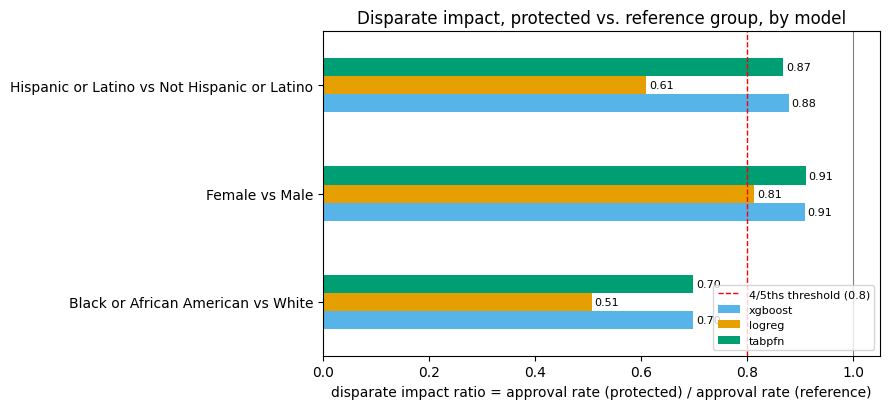

In [11]:
df = pair_rows("dir")
if not df.empty:
    pivot = df.pivot(index="comparison", columns="model", values="value")
    pivot = pivot[[m for m in MODELS_RUN if m in pivot.columns]]
    fig, ax = plt.subplots(figsize=(9, 1.5 + 0.9 * len(pivot)))
    pivot.plot(kind="barh", ax=ax, color=[MODEL_COLORS[m] for m in pivot.columns])
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
    ax.axvline(0.8, color="red", ls="--", lw=1, label="4/5ths threshold (0.8)")
    ax.axvline(1.0, color="gray", lw=0.8)
    ax.set_xlabel("disparate impact ratio = approval rate (protected) / approval rate (reference)")
    ax.set_ylabel("")
    ax.set_title("Disparate impact, protected vs. reference group, by model")
    ax.legend(loc="lower right", fontsize=8)
    save(fig, "fairness_disparate_impact_pair.png")

### Disparate impact — all categories, min/max (secondary)

Kept for completeness and for the age attributes (no pair yet). Read with care: the lowest and
highest categories are often "Joint", "... Not Available", or a category with a few hundred
applicants, not the demographic comparison the rule is about.

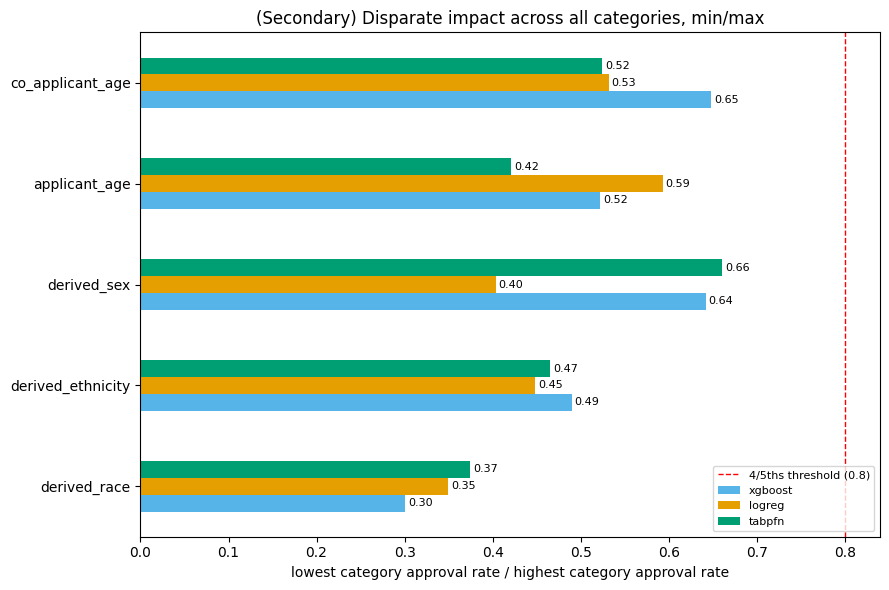

In [12]:
rows = []
for name in MODELS_RUN:
    for col in cm.AUDIT_COLS:
        fl = fairlearn_entry(name, col)
        if fl:
            rows.append({"model": name, "attribute": col, "value": fl["demographic_parity_ratio"]})
if rows:
    pivot = pd.DataFrame(rows).pivot(index="attribute", columns="model", values="value").reindex(cm.AUDIT_COLS)
    pivot = pivot[[m for m in MODELS_RUN if m in pivot.columns]]
    fig, ax = plt.subplots(figsize=(9, 1.5 + 0.9 * len(pivot)))
    pivot.plot(kind="barh", ax=ax, color=[MODEL_COLORS[m] for m in pivot.columns])
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
    ax.axvline(0.8, color="red", ls="--", lw=1, label="4/5ths threshold (0.8)")
    ax.set_xlabel("lowest category approval rate / highest category approval rate")
    ax.set_ylabel("")
    ax.set_title("(Secondary) Disparate impact across all categories, min/max")
    ax.legend(loc="lower right", fontsize=8)
    save(fig, "fairness_disparate_impact_all_groups.png")

### Fairness equivalence (TOST)

Point = approval-rate gap (protected − reference), bar = 90% CI. A CI entirely inside the green
±δ band is equivalent within δ at α = 0.05; a CI that crosses the band edge is not.

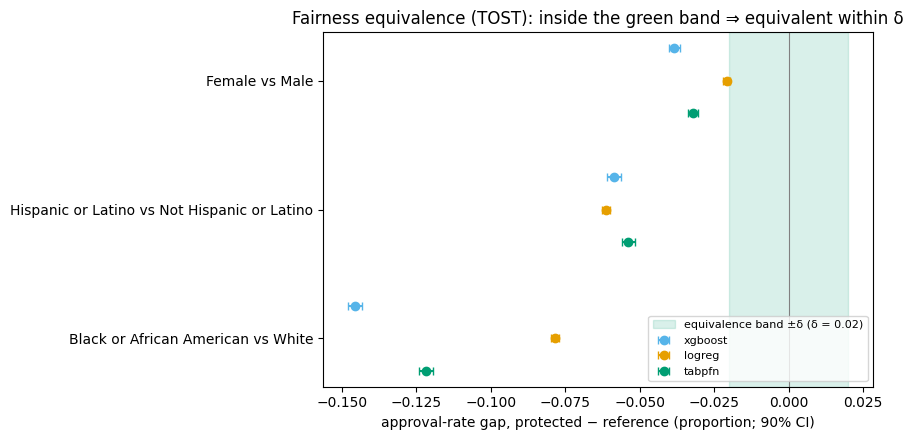

In [13]:
eq_rows = []
for name in MODELS_RUN:
    for col, pair in FAIRNESS_PAIRS.items():
        eq = fairness_results[name].get(col, {}).get("equivalence")
        if eq:
            eq_rows.append({"comparison": f"{pair[0]} vs {pair[1]}", "model": name, **eq})
if eq_rows:
    eq_df = pd.DataFrame(eq_rows)
    comparisons = list(dict.fromkeys(eq_df["comparison"]))
    offsets = dict(zip(MODELS_RUN, np.linspace(-0.25, 0.25, len(MODELS_RUN)) if len(MODELS_RUN) > 1 else [0.0]))
    fig, ax = plt.subplots(figsize=(9, 1.5 + 1.0 * len(comparisons)))
    ax.axvspan(-DELTA, DELTA, color="#009E73", alpha=0.15, label=f"equivalence band ±δ (δ = {DELTA})")
    ax.axvline(0, color="gray", lw=0.8)
    for name in MODELS_RUN:
        sub = eq_df[eq_df["model"] == name]
        if sub.empty:
            continue
        y_pos = [comparisons.index(c) + offsets[name] for c in sub["comparison"]]
        err = [sub["theta_hat"] - sub["ci_low"], sub["ci_high"] - sub["theta_hat"]]
        ax.errorbar(sub["theta_hat"], y_pos, xerr=err, fmt="o", capsize=3, color=MODEL_COLORS[name], label=name)
    ax.set_yticks(range(len(comparisons)))
    ax.set_yticklabels(comparisons)
    ax.invert_yaxis()
    ax.set_xlabel("approval-rate gap, protected − reference (proportion; 90% CI)")
    ax.set_title("Fairness equivalence (TOST): inside the green band ⇒ equivalent within δ")
    ax.legend(loc="lower right", fontsize=8)
    save(fig, "fairness_tost_equivalence.png")

### Equalized odds — protected vs. reference (Separation)

Gap in true positive rate (qualified applicants approved) and false positive rate (unqualified
applicants approved), protected minus reference. Zero on both is equalized odds; the reported
equalized-odds difference is the larger of the two absolute gaps.

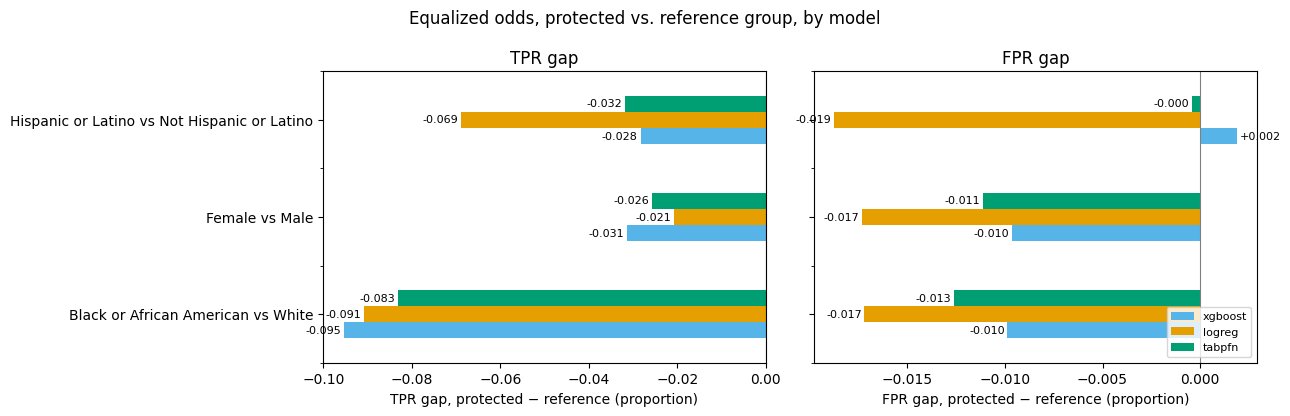

In [14]:
tpr_df, fpr_df = pair_rows("tpr_gap"), pair_rows("fpr_gap")
if not tpr_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 1.5 + 0.9 * tpr_df["comparison"].nunique()), sharey=True)
    for ax, df, title in [(axes[0], tpr_df, "TPR gap"), (axes[1], fpr_df, "FPR gap")]:
        pivot = df.pivot(index="comparison", columns="model", values="value")
        pivot = pivot[[m for m in MODELS_RUN if m in pivot.columns]]
        pivot.plot(kind="barh", ax=ax, color=[MODEL_COLORS[m] for m in pivot.columns], legend=ax is axes[1])
        for container in ax.containers:
            ax.bar_label(container, fmt="%+.3f", padding=2, fontsize=8)
        ax.axvline(0, color="gray", lw=0.8)
        ax.set_xlabel(f"{title}, protected − reference (proportion)")
        ax.set_ylabel("")
        ax.set_title(title)
    axes[1].legend(loc="lower right", fontsize=8)
    fig.suptitle("Equalized odds, protected vs. reference group, by model")
    save(fig, "fairness_equalized_odds_pair.png")

### Per attribute — approval rate by group, all models side by side

Dashed line = that model's overall approval rate. Group size `n` is from the full test set.

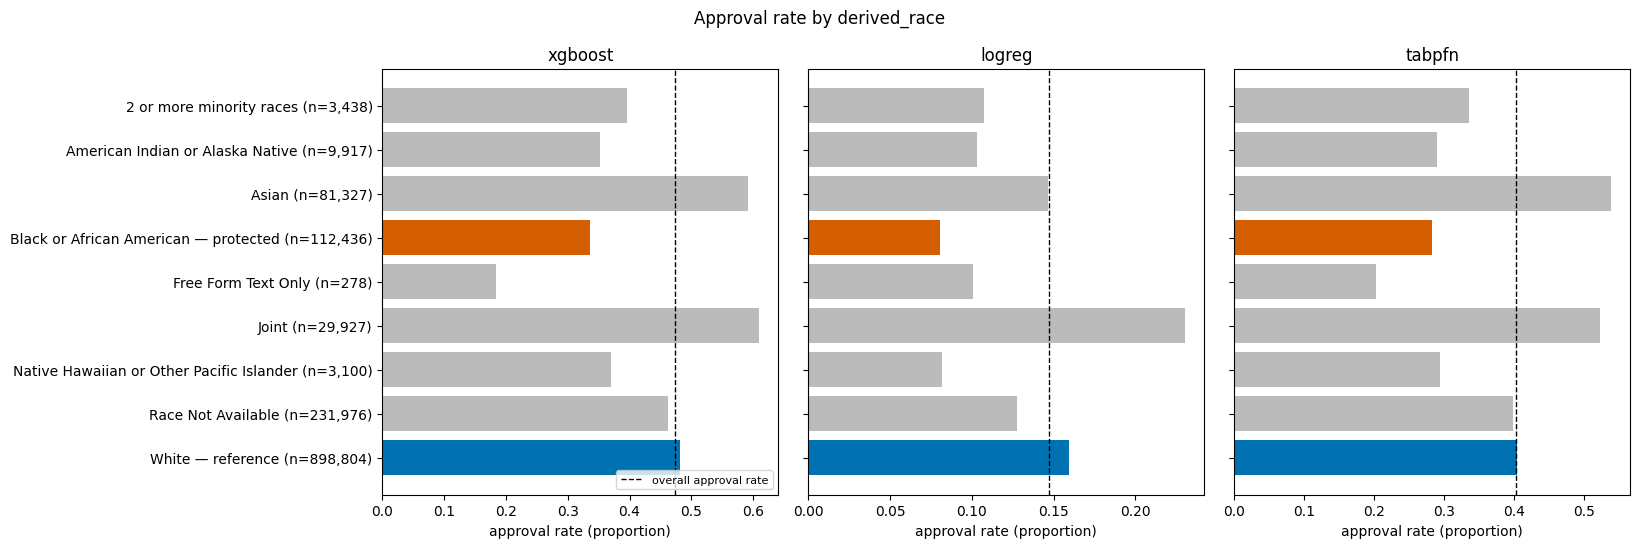

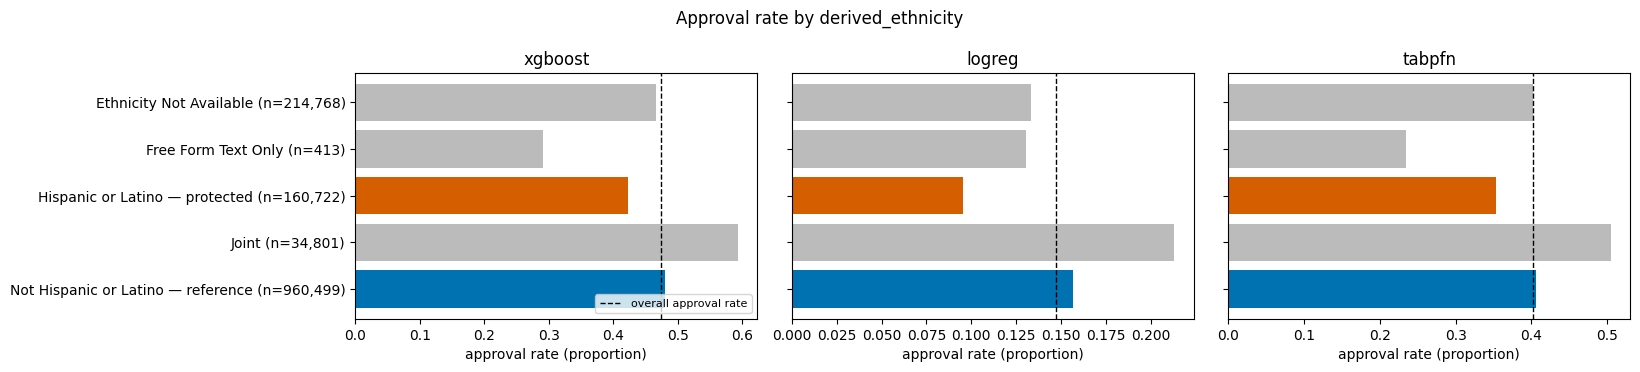

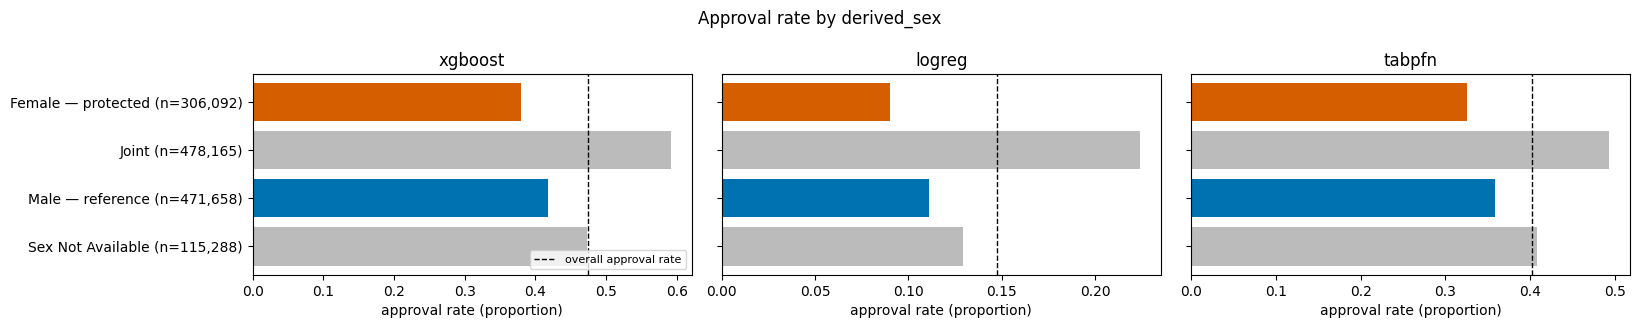

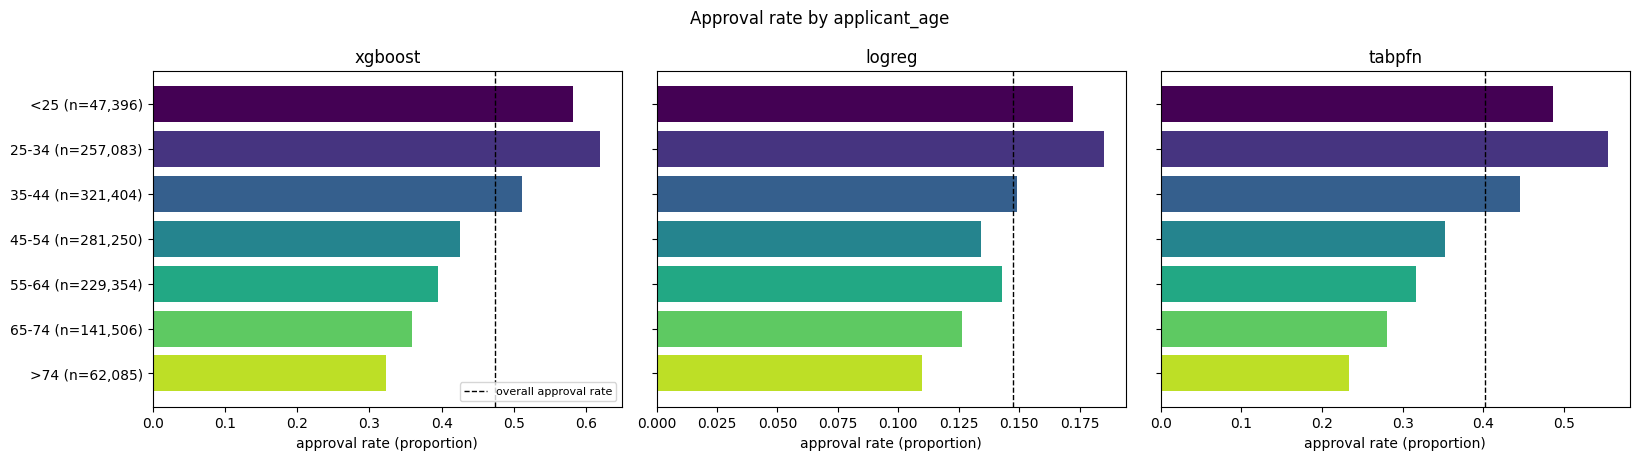

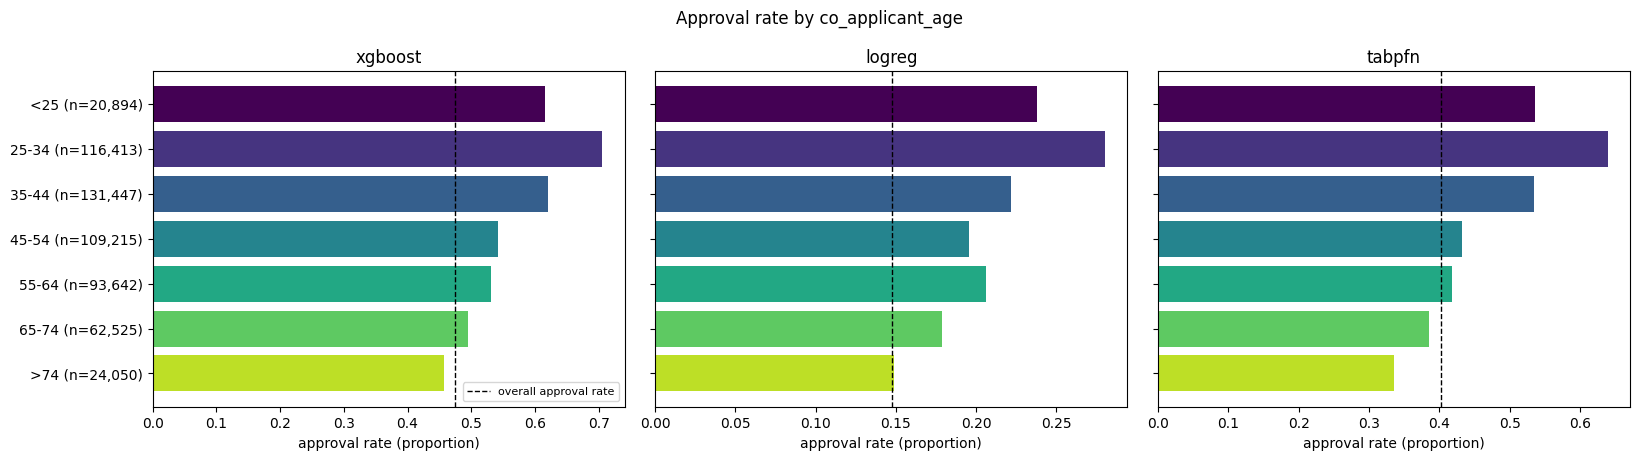

In [15]:
for col in cm.AUDIT_COLS:
    present = [m for m in MODELS_RUN if fairlearn_entry(m, col)]
    if not present:
        continue
    groups = order_groups(set().union(*[fairlearn_entry(m, col)["by_group"].index for m in present]), col)
    colors = group_colors(groups, col)
    fig, axes = plt.subplots(1, len(present), figsize=(4.5 * len(present) + 3, 1.5 + 0.45 * len(groups)), sharey=True, squeeze=False)
    for ax, name in zip(axes[0], present):
        rates = fairlearn_entry(name, col)["by_group"]["selection_rate"].reindex(groups)
        ax.barh(range(len(groups)), rates, color=[colors[g] for g in groups])
        ax.axvline(fairness_results[name]["approval_rate"], color="black", ls="--", lw=1, label="overall approval rate")
        ax.set_title(name)
        ax.set_xlabel("approval rate (proportion)")
    axes[0][0].set_yticks(range(len(groups)))
    axes[0][0].set_yticklabels([group_label(g, col) for g in groups])
    axes[0][0].invert_yaxis()
    axes[0][0].legend(loc="lower right", fontsize=8)
    fig.suptitle(f"Approval rate by {col}")
    save(fig, f"fairness_approval_rate_{col}.png")

### Per attribute — true and false positive rates by group (Separation)

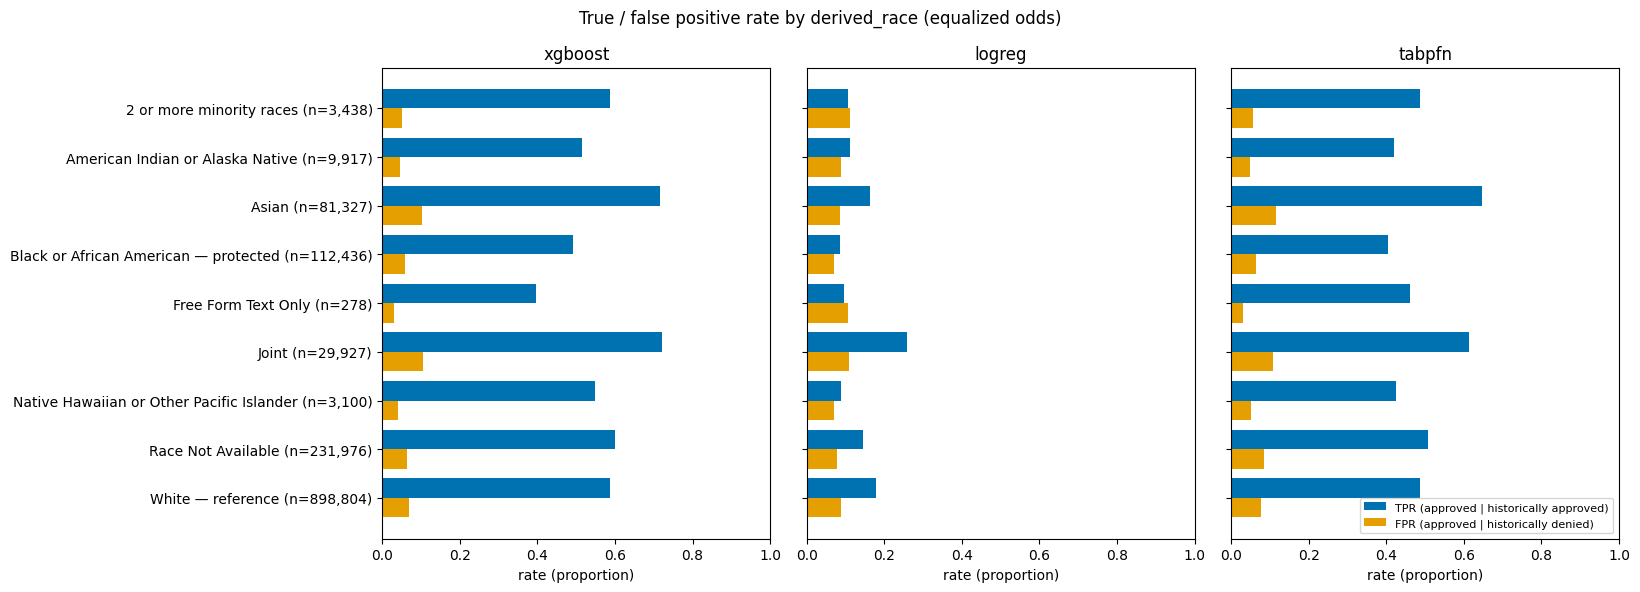

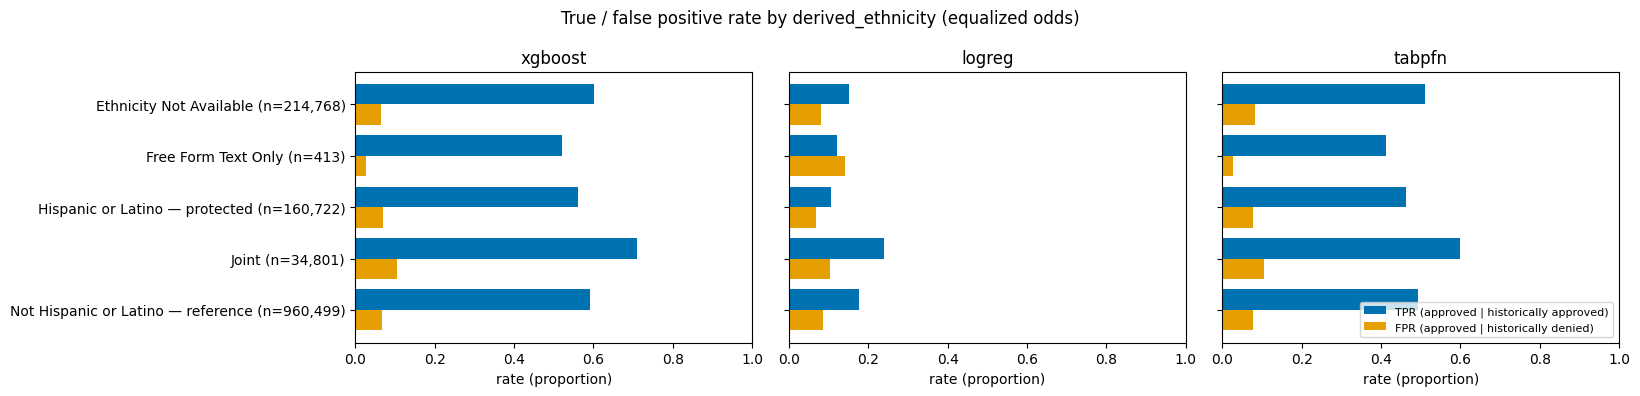

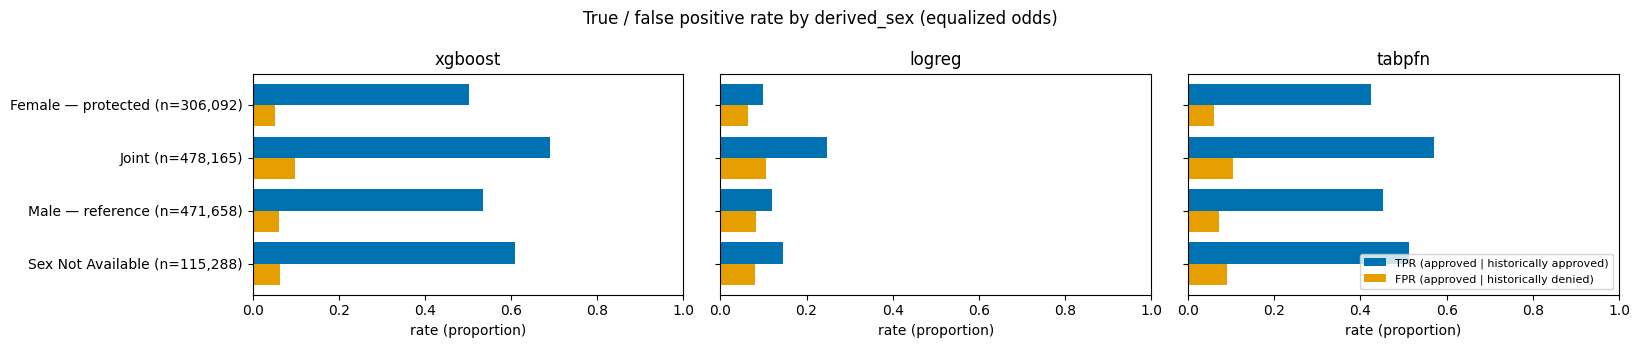

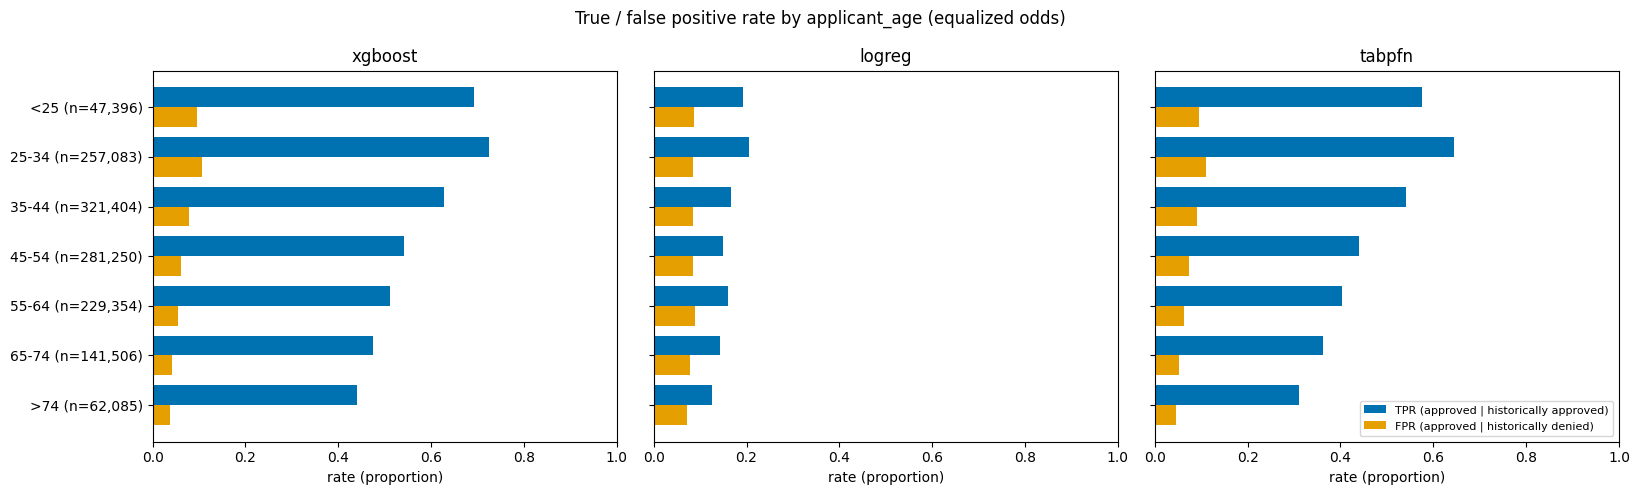

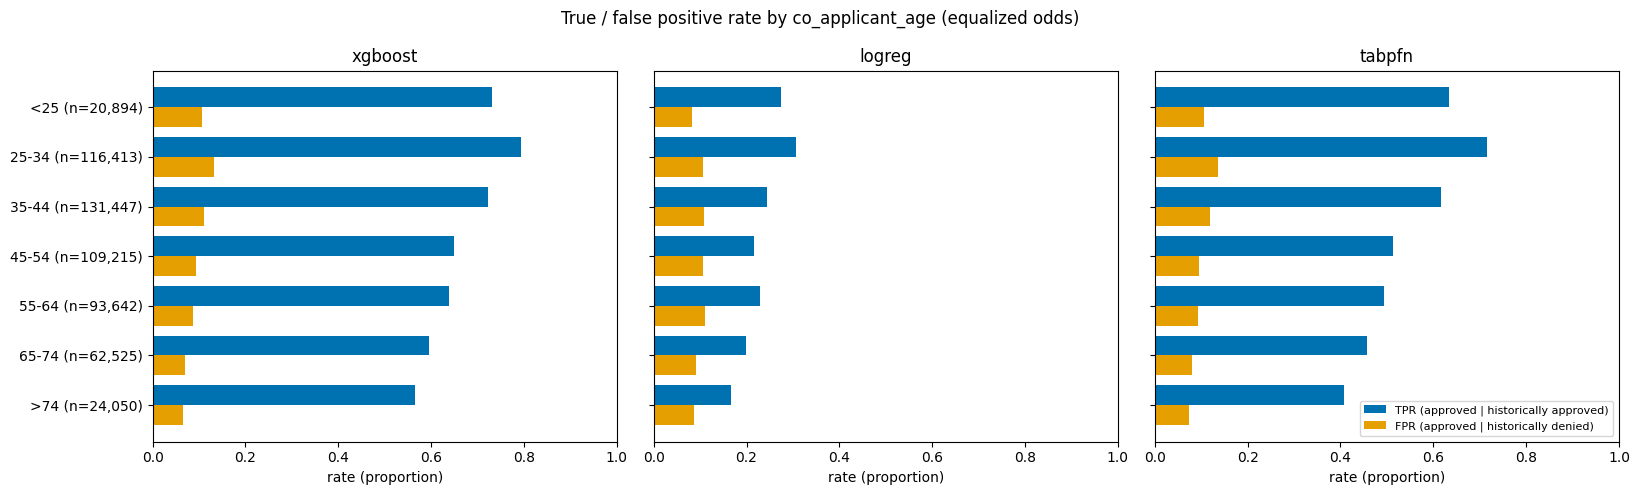

In [16]:
for col in cm.AUDIT_COLS:
    present = [m for m in MODELS_RUN if fairlearn_entry(m, col)]
    if not present:
        continue
    groups = order_groups(set().union(*[fairlearn_entry(m, col)["by_group"].index for m in present]), col)
    y = np.arange(len(groups))
    fig, axes = plt.subplots(1, len(present), figsize=(4.5 * len(present) + 3, 1.5 + 0.5 * len(groups)), sharey=True, squeeze=False)
    for ax, name in zip(axes[0], present):
        bg = fairlearn_entry(name, col)["by_group"].reindex(groups)
        ax.barh(y - 0.2, bg["tpr"], height=0.4, color="#0072B2", label="TPR (approved | historically approved)")
        ax.barh(y + 0.2, bg["fpr"], height=0.4, color="#E69F00", label="FPR (approved | historically denied)")
        ax.set_xlim(0, 1)
        ax.set_title(name)
        ax.set_xlabel("rate (proportion)")
    axes[0][0].set_yticks(y)
    axes[0][0].set_yticklabels([group_label(g, col) for g in groups])
    axes[0][0].invert_yaxis()
    axes[0][-1].legend(loc="lower right", fontsize=8)
    fig.suptitle(f"True / false positive rate by {col} (equalized odds)")
    save(fig, f"fairness_error_rates_{col}.png")

### Per attribute — calibration by group (Sufficiency)

Each point is one score decile: mean predicted approval probability vs. the share of those
applicants actually approved historically. On the diagonal = calibrated. A group whose curve sits
consistently below the others is scored higher than its outcomes justify (and vice versa).

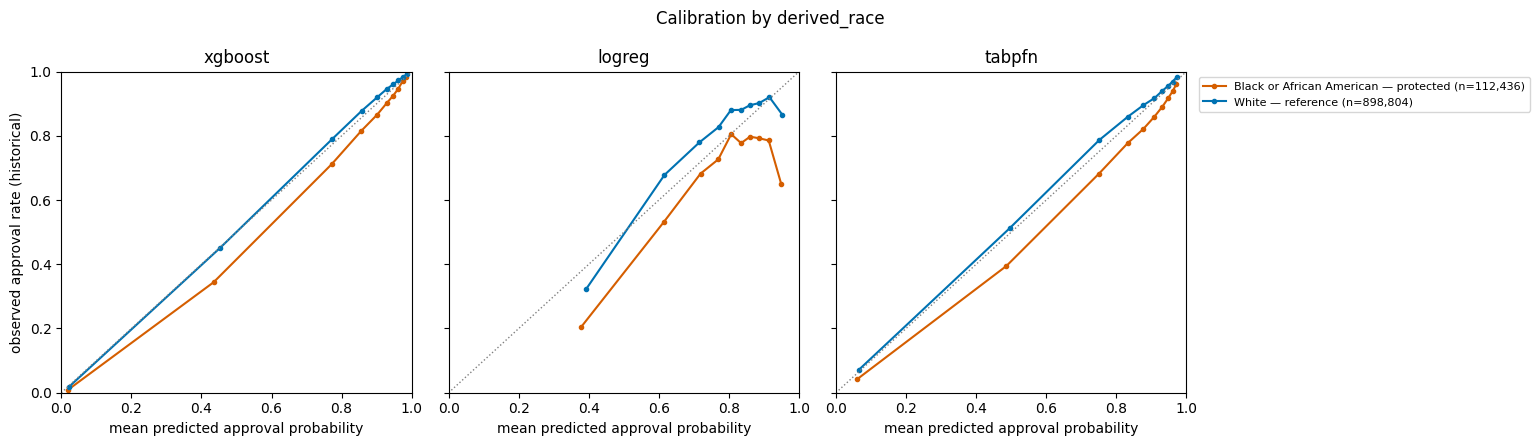

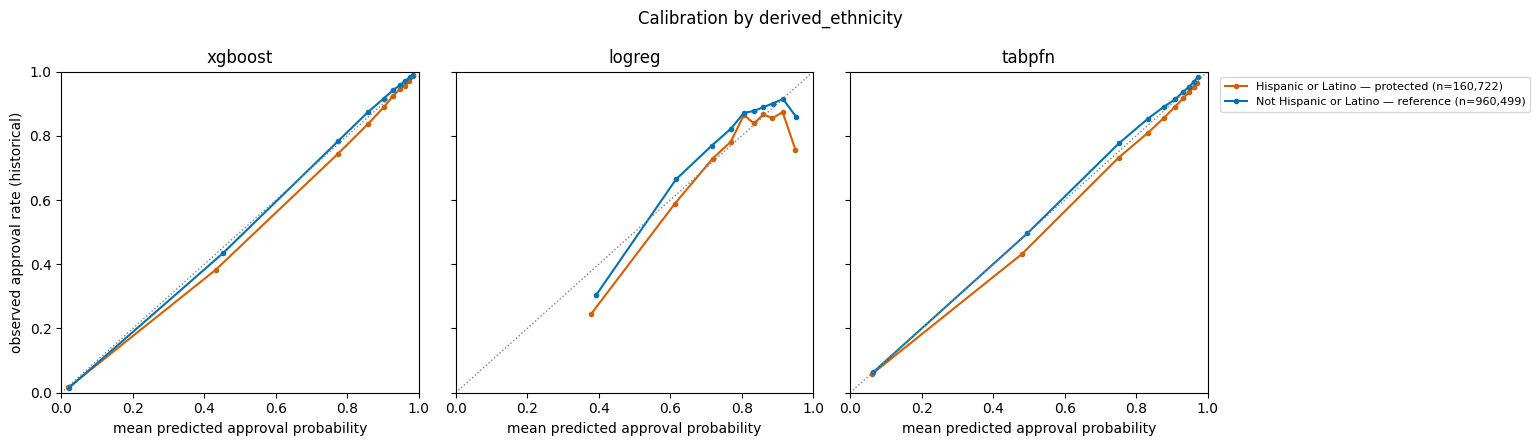

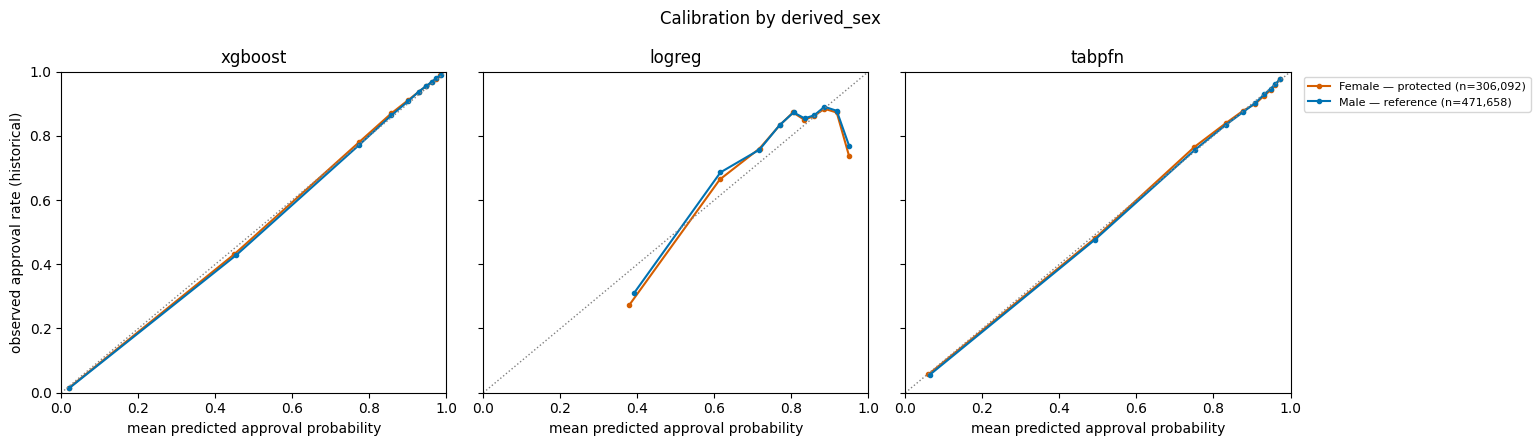

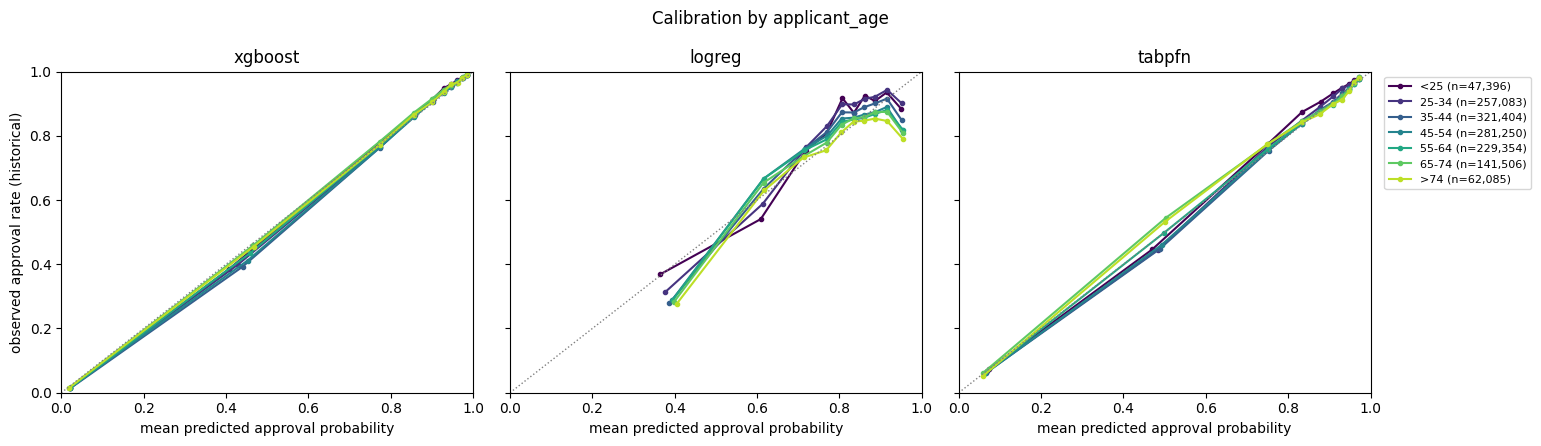

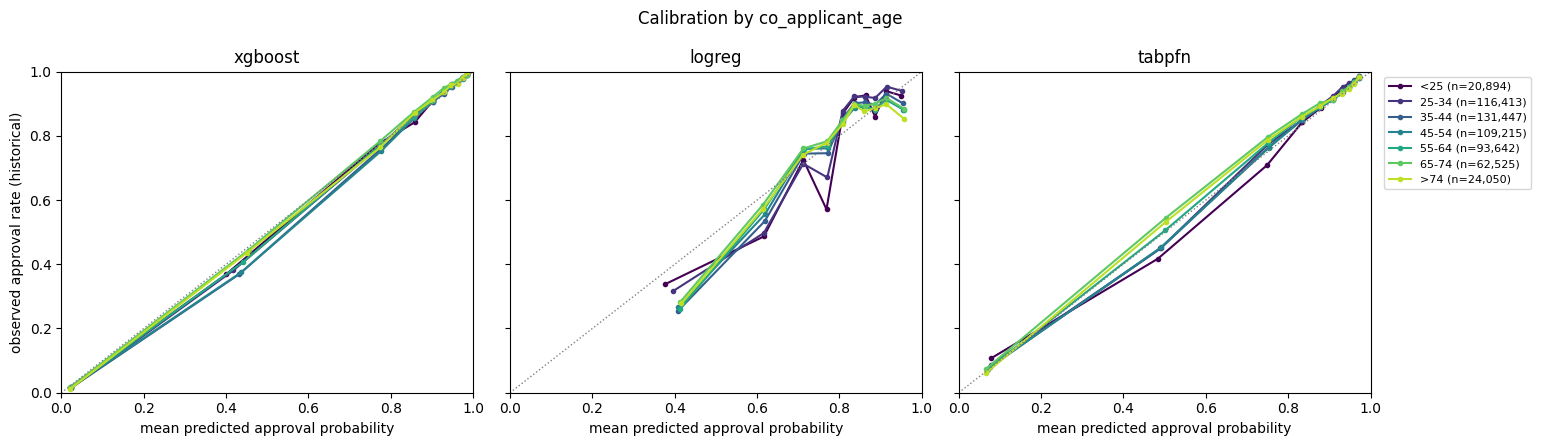

In [17]:
for col in cm.AUDIT_COLS:
    present = [m for m in MODELS_RUN if fairness_results[m].get(col, {}).get("calibration_curves")]
    if not present:
        continue
    groups = curve_groups(col)
    colors = group_colors(groups, col)
    fig, axes = plt.subplots(1, len(present), figsize=(4.5 * len(present) + 2, 4.5), sharex=True, sharey=True, squeeze=False)
    for ax, name in zip(axes[0], present):
        curves = fairness_results[name][col]["calibration_curves"]
        for g in groups:
            if g in curves and not curves[g].empty:
                ax.plot(curves[g]["mean_predicted"], curves[g]["observed_rate"], marker="o", ms=3, color=colors[g], label=group_label(g, col))
        ax.plot([0, 1], [0, 1], color="gray", ls=":", lw=1)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(name)
        ax.set_xlabel("mean predicted approval probability")
    axes[0][0].set_ylabel("observed approval rate (historical)")
    axes[0][-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    fig.suptitle(f"Calibration by {col}")
    save(fig, f"fairness_calibration_{col}.png")

### Per attribute — conditional parity: approval rate within risk bands

Applicants binned into quintiles of each risk score first; each line is one group's approval rate
within each band. Lines that stay apart across every band mean the gap isn't explained by that
risk measure.

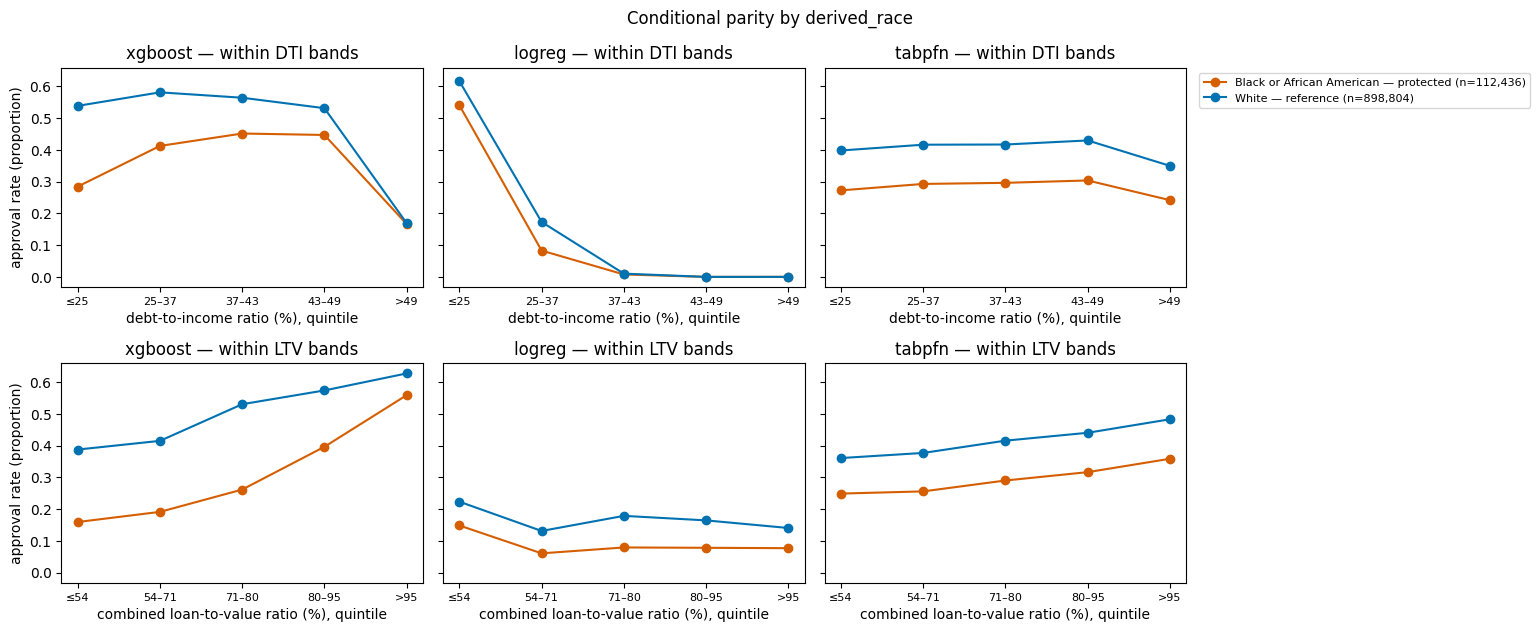

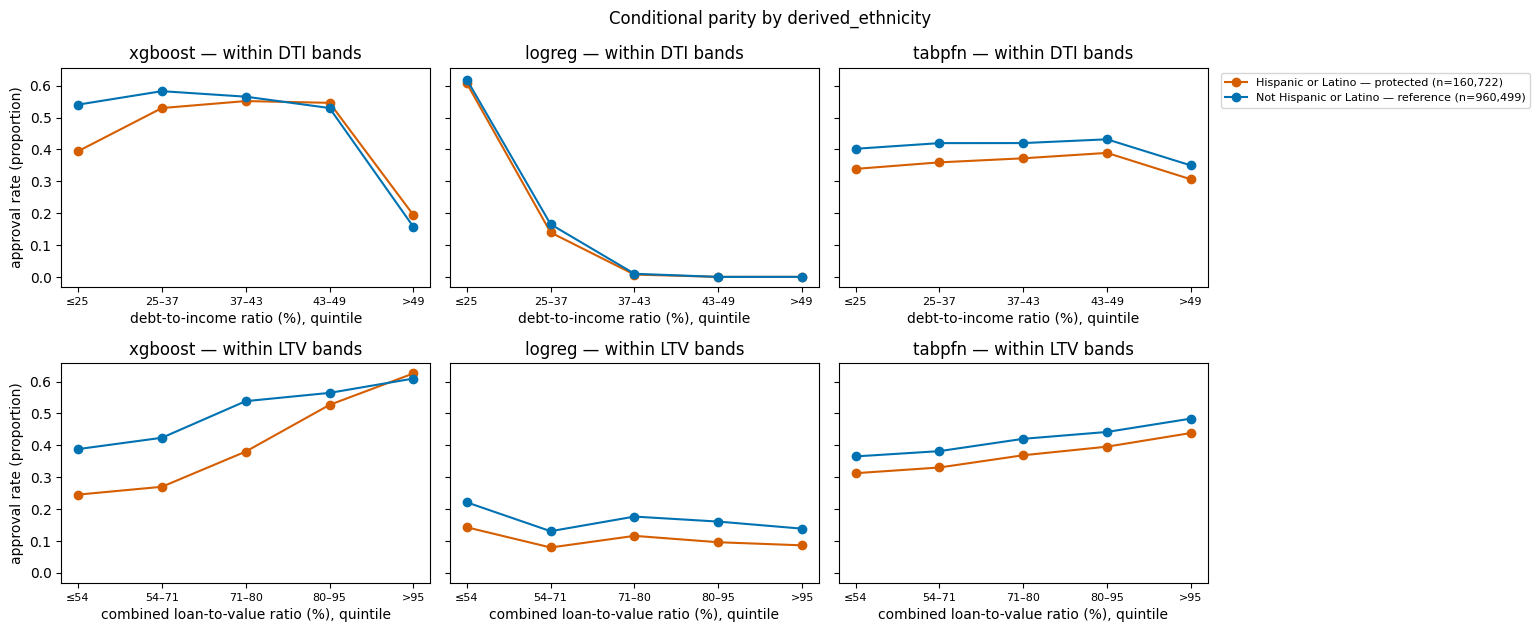

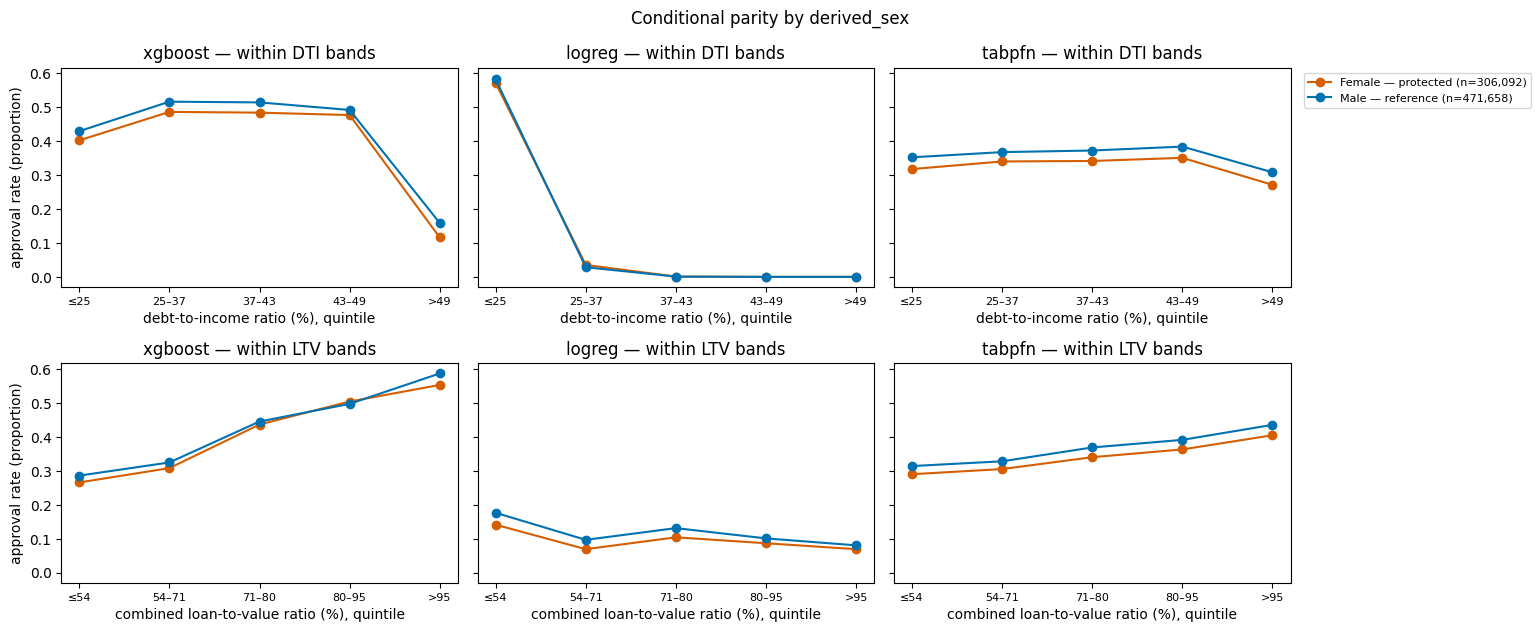

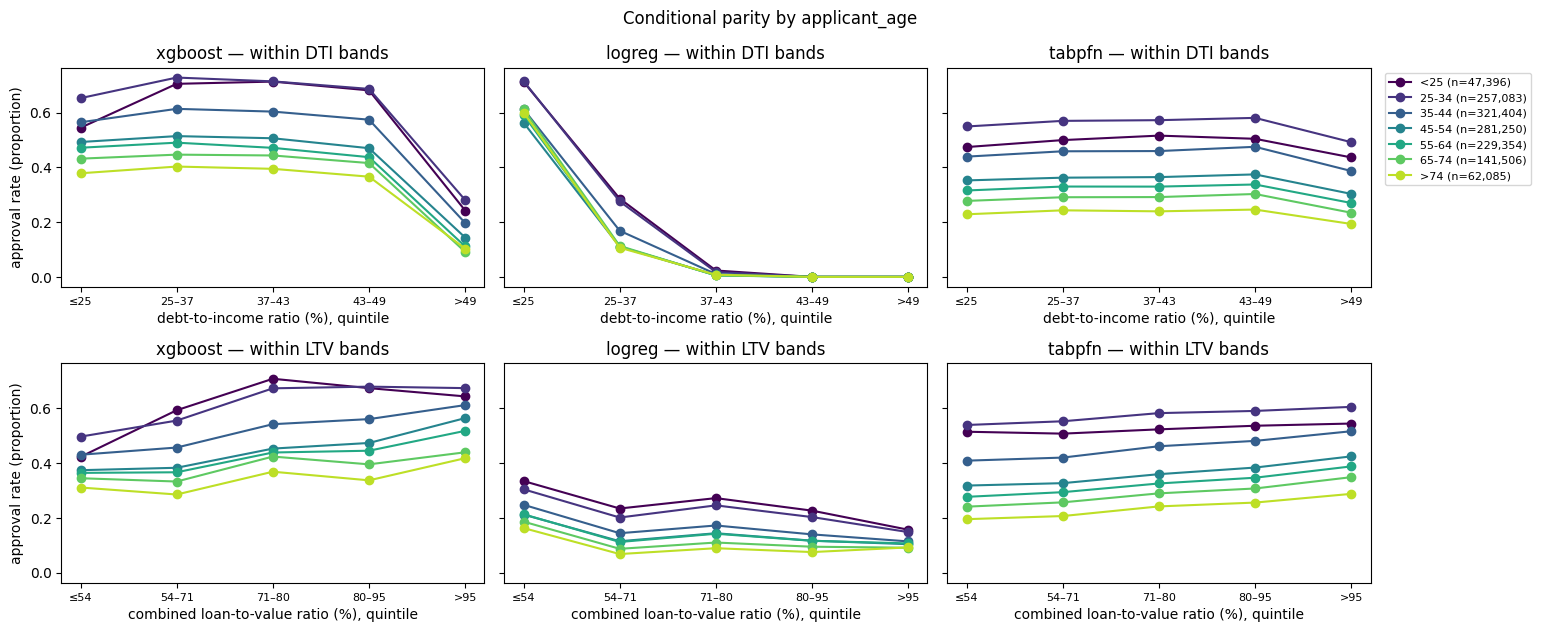

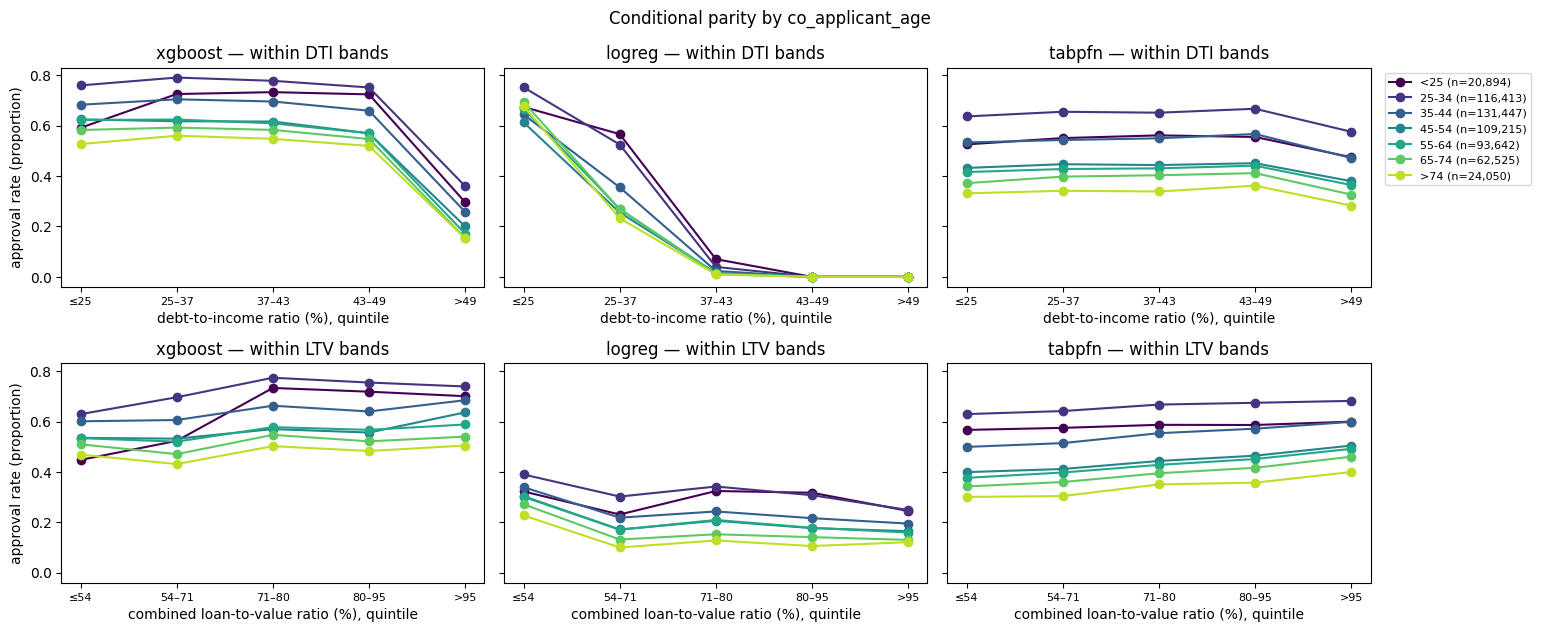

In [18]:
for col in cm.AUDIT_COLS:
    present = [m for m in MODELS_RUN if fairness_results[m].get(col, {}).get("conditional_parity_curves")]
    if not present:
        continue
    groups = curve_groups(col)
    colors = group_colors(groups, col)
    fig, axes = plt.subplots(len(RISK_SCORE_COLS), len(present), figsize=(4.5 * len(present) + 2, 3.2 * len(RISK_SCORE_COLS)), sharey=True, squeeze=False)
    for row, risk_col in enumerate(RISK_SCORE_COLS):
        for ax, name in zip(axes[row], present):
            table = fairness_results[name][col]["conditional_parity_curves"][risk_col]
            x = np.arange(len(table))
            for g in groups:
                if g in table.columns:
                    ax.plot(x, table[g], marker="o", color=colors[g], label=group_label(g, col))
            ax.set_xticks(x)
            ax.set_xticklabels(band_labels(table.index), fontsize=8)
            ax.set_xlabel(f"{FEATURE_LABELS[risk_col]}, quintile")
            ax.set_title(f"{name} — within {RISK_SHORT[risk_col]} bands")
        axes[row][0].set_ylabel("approval rate (proportion)")
    axes[0][-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    fig.suptitle(f"Conditional parity by {col}")
    save(fig, f"fairness_conditional_parity_{col}.png")

### FPDP — how the protected-vs-reference gap moves with each risk feature

One line per model. Only drawn for attributes whose Independence test rejected (always, at this
sample size) and that have a named pair.

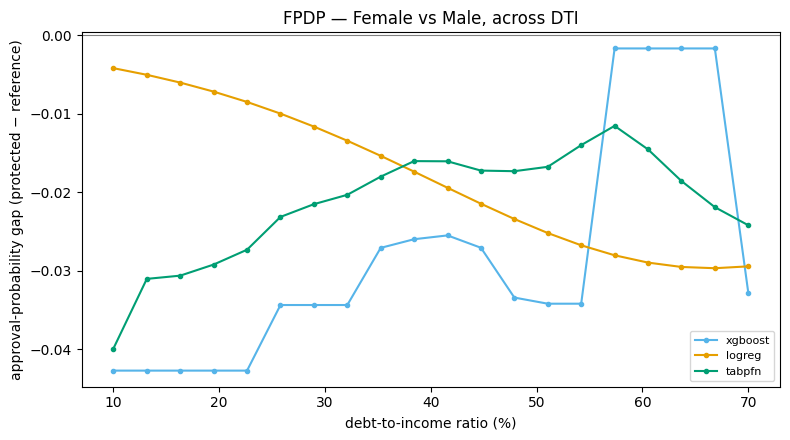

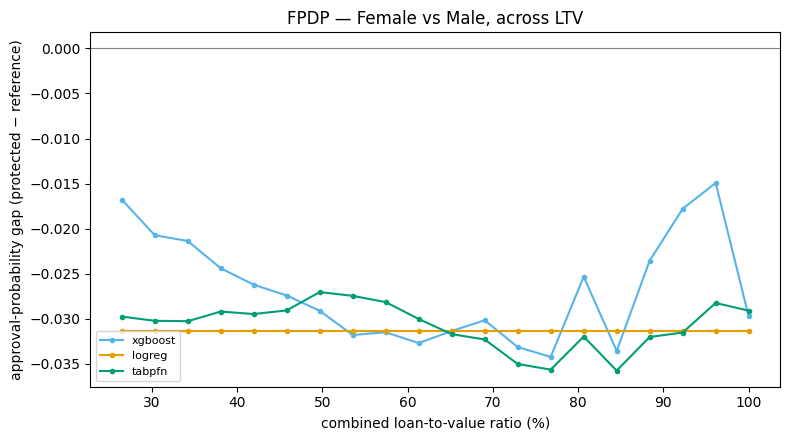

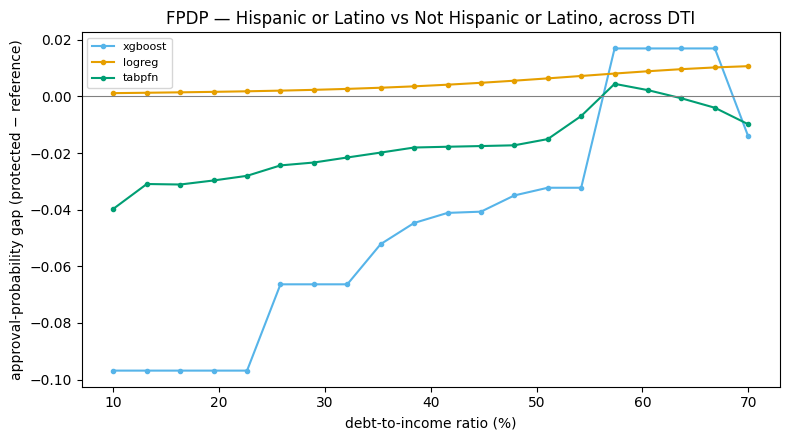

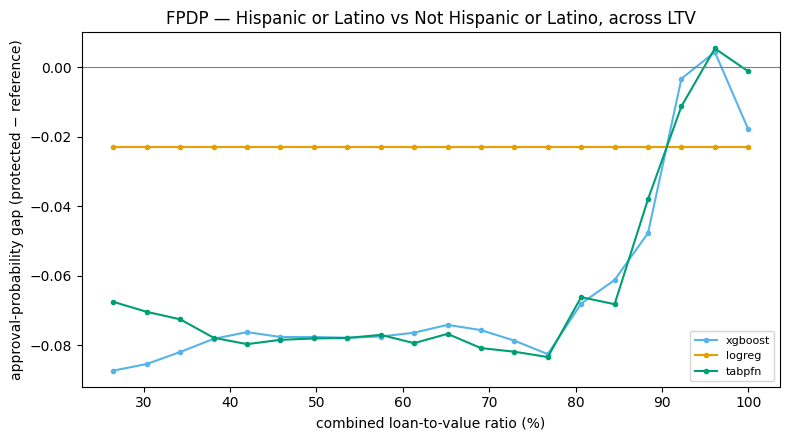

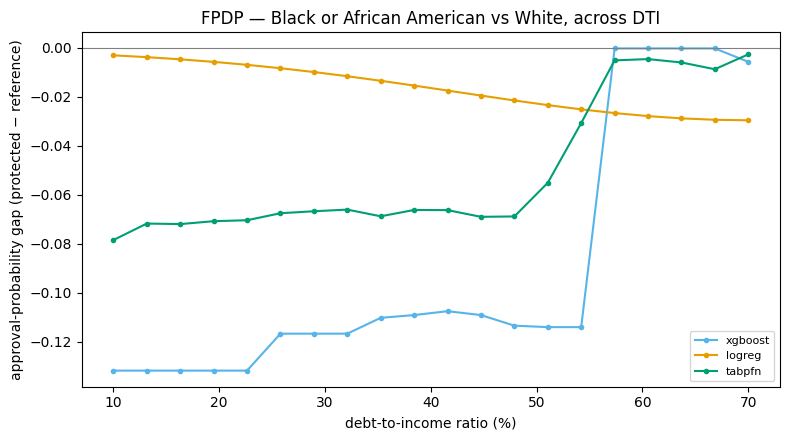

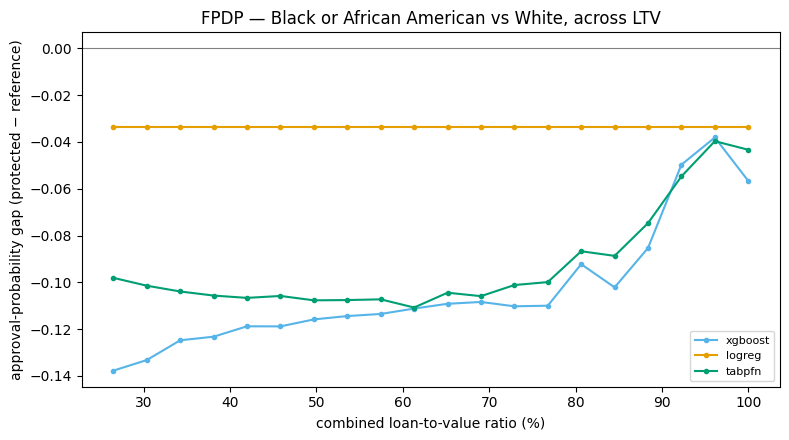

In [19]:
for col, pair in FAIRNESS_PAIRS.items():
    if not pair:
        continue
    for feature in RISK_SCORE_COLS:
        lines = {m: fairness_results[m].get(col, {}).get("fpdp", {}).get(feature) for m in MODELS_RUN}
        lines = {m: v for m, v in lines.items() if v}
        if not lines:
            continue
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for name, disparities in lines.items():
            vals, gaps = zip(*disparities)
            ax.plot(vals, gaps, marker="o", ms=3, color=MODEL_COLORS[name], label=name)
        ax.axhline(0, color="gray", lw=0.8)
        ax.set_xlabel(FEATURE_LABELS[feature])
        ax.set_ylabel("approval-probability gap (protected − reference)")
        ax.set_title(f"FPDP — {pair[0]} vs {pair[1]}, across {RISK_SHORT[feature]}")
        ax.legend(fontsize=8)
        save(fig, f"fairness_fpdp_{col}_{feature}.png")

## Summary tables — copy-ready for the slide deck

**Detail** — one row per model × attribute, every number the notebook computes. p-values below
1e-4 are shown as `<1e-4`; with ~1.37M rows the classical tests reject almost everything, which
is exactly why TOST is the primary test here.

**Summary** — one row per model. `approval rate` is worth watching — the same `TEAM_THRESHOLD`
can imply very different approval rates per model depending on how spread out each model's
probabilities are (see `common_metrics.py`).

In [20]:
def fmt_p(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return "—"
    return "<1e-4" if p < 1e-4 else f"{p:.4f}"


detail_rows = []
for name in MODELS_RUN:
    for col in cm.AUDIT_COLS:
        entry = fairness_results[name].get(col, {})
        pair = FAIRNESS_PAIRS.get(col)
        fl = entry.get("fairlearn")
        pm = pair_metrics(fl["by_group"], pair) if fl else None
        eq = entry.get("equivalence")
        tests = entry.get("test", {})
        cp = entry.get("conditional_parity", {})
        detail_rows.append({
            "model": name,
            "attribute": col,
            "comparison": f"{pair[0]} vs {pair[1]}" if pair else "—",
            "approval gap (P − R)": round(eq["theta_hat"], 4) if eq else "—",
            "90% CI": f"[{eq['ci_low']:.4f}, {eq['ci_high']:.4f}]" if eq else "—",
            "TOST p": fmt_p(eq["tost_p"]) if eq else "—",
            f"equivalent (±{DELTA})": ("yes" if eq["equivalent"] else "no") if eq else "—",
            "DIR (pair)": round(pm["dir"], 3) if pm else "—",
            "DIR (all groups)": round(fl["demographic_parity_ratio"], 3) if fl else "—",
            "EOD (pair)": round(pm["eod"], 3) if pm else "—",
            "EOD (all groups)": round(fl["equalized_odds_difference"], 3) if fl else "—",
            "p independence": fmt_p(tests.get("independence", {}).get("p_value")),
            "p separation": fmt_p(tests.get("separation", {}).get("p_value")),
            "p sufficiency": fmt_p(tests.get("sufficiency", {}).get("p_value")),
            **{f"p cond. parity ({RISK_SHORT[r]})": fmt_p(cp.get(r, {}).get("p_value")) for r in RISK_SCORE_COLS},
        })
fairness_detail_df = pd.DataFrame(detail_rows)

summary_rows = []
for name in MODELS_RUN:
    pms, eqs, fls = [], [], []
    for col in cm.AUDIT_COLS:
        entry = fairness_results[name].get(col, {})
        fl = entry.get("fairlearn")
        pm = pair_metrics(fl["by_group"], FAIRNESS_PAIRS.get(col)) if fl else None
        if pm:
            pms.append((col, pm))
        if fl:
            fls.append(fl)
        if entry.get("equivalence"):
            eqs.append(entry["equivalence"])
    worst = min(pms, key=lambda item: item[1]["dir"]) if pms else None
    summary_rows.append({
        "model": name,
        "approval rate": round(fairness_results[name]["approval_rate"], 4),
        "lowest DIR (pair)": f"{worst[1]['dir']:.3f} ({worst[0]})" if worst else "—",
        "pairs below 4/5ths": f"{sum(pm['dir'] < 0.8 for _, pm in pms)}/{len(pms)}" if pms else "—",
        "largest EOD (pair)": round(max(pm["eod"] for _, pm in pms), 3) if pms else "—",
        f"pairs equivalent (±{DELTA})": f"{sum(e['equivalent'] for e in eqs)}/{len(eqs)}" if eqs else "—",
        "lowest DIR (all groups)": round(min(fl["demographic_parity_ratio"] for fl in fls), 3) if fls else "—",
    })
fairness_summary_df = pd.DataFrame(summary_rows)

display(fairness_summary_df)
display(fairness_detail_df)

,model,approval rate,lowest DIR (pair),pairs below 4/5ths,largest EOD (pair),pairs equivalent (±0.02),lowest DIR (all groups)
0,xgboost,0.4744,0.698 (derived_race),1/3,0.095,0/3,0.301
1,logreg,0.1474,0.507 (derived_race),2/3,0.091,0/3,0.350
2,tabpfn,0.4021,0.698 (derived_race),1/3,0.083,0/3,0.375


,model,attribute,comparison,approval gap (P − R),90% CI,TOST p,equivalent (±0.02),DIR (pair),DIR (all groups),EOD (pair),EOD (all groups),p independence,p separation,p sufficiency,p cond. parity (DTI),p cond. parity (LTV)
0,xgboost,derived_race,Black or African American vs White,-0.1455,"[-0.1480, -0.1431]",1.0000,no,0.698,0.301,0.095,0.325,<1e-4,<1e-4,<1e-4,<1e-4,<1e-4
1,xgboost,derived_ethnicity,Hispanic or Latino vs Not Hispanic or Latino,-0.0586,"[-0.0608, -0.0564]",1.0000,no,0.878,0.490,0.028,0.188,<1e-4,<1e-4,<1e-4,<1e-4,<1e-4
2,xgboost,derived_sex,Female vs Male,-0.0383,"[-0.0402, -0.0365]",1.0000,no,0.908,0.642,0.031,0.188,<1e-4,<1e-4,<1e-4,<1e-4,<1e-4
3,xgboost,applicant_age,—,—,—,—,—,—,0.522,—,0.284,<1e-4,<1e-4,<1e-4,<1e-4,<1e-4
4,xgboost,co_applicant_age,—,—,—,—,—,—,0.648,—,0.227,<1e-4,<1e-4,<1e-4,<1e-4,<1e-4
5,logreg,derived_race,Black or African American vs White,-0.0785,"[-0.0799, -0.0771]",1.0000,no,0.507,0.350,0.091,0.171,<1e-4,<1e-4,<1e-4,<1e-4,<1e-4
6,logreg,derived_ethnicity,Hispanic or Latino vs Not Hispanic or Latino,-0.0612,"[-0.0626, -0.0599]",1.0000,no,0.609,0.448,0.069,0.132,<1e-4,<1e-4,<1e-4,<1e-4,<1e-4
7,logreg,derived_sex,Female vs Male,-0.0208,"[-0.0220, -0.0197]",0.8824,no,0.813,0.403,0.021,0.148,<1e-4,<1e-4,<1e-4,<1e-4,<1e-4
8,logreg,applicant_age,—,—,—,—,—,—,0.593,—,0.080,<1e-4,<1e-4,<1e-4,<1e-4,<1e-4
9,logreg,co_applicant_age,—,—,—,—,—,—,0.532,—,0.141,<1e-4,<1e-4,<1e-4,<1e-4,<1e-4


## Smoke test — remove once real models are in `models/`

Runs the same pipeline on a throwaway logistic regression and a small sample,
purely to check the harness works end to end.

In [21]:
if not fairness_results:
    print("Running a throwaway smoke test — NOT a real model, just checking the harness works end to end.")
    sample = train_df.sample(20_000, random_state=42)
    Xs, ys = cm.get_X_y(sample)
    test_sample = test_df.sample(5_000, random_state=42)
    Xt, yt = cm.get_X_y(test_sample)
    smoke_model = cm.SmokeTestModule.fit(Xs, ys)
    smoke_probs = cm.SmokeTestModule.predict_proba(smoke_model, Xt)[:, 1]
    smoke_audit = cm.get_audit(test_sample).reset_index(drop=True)
    smoke_audit["y_true"] = yt.reset_index(drop=True)
    smoke_audit["y_pred_proba"] = smoke_probs
    smoke_audit["y_pred"] = (smoke_probs >= cm.TEAM_THRESHOLD).astype(int)
    print(fairness_test(smoke_audit, "derived_sex"))
    print("Harness is wired correctly.")

## Save outputs

Writes to `outputs/evaluation/fairness/` so results survive independently of the notebook.
The chart PNGs are committed to git; the CSV tables and `.pkl` results/checkpoints are
gitignored (`*.csv`, `*.pkl`) and stay local. Individual attribute results are already
checkpointed as they run (see above); this writes the final consolidated summary, detail
table, and full results for convenience. No model objects are stored in `fairness_results`, so
the whole thing is pickled as-is.

In [22]:
import pickle

if fairness_results:
    fairness_summary_df.to_csv(NB_OUTPUT_DIR / "fairness_summary.csv", index=False)
    fairness_detail_df.to_csv(NB_OUTPUT_DIR / "fairness_detail.csv", index=False)
    with open(NB_OUTPUT_DIR / "fairness_results.pkl", "wb") as f:
        pickle.dump(fairness_results, f)
    print(f"Saved summary + full results to {NB_OUTPUT_DIR}/")

Saved summary + full results to /users/eleves-a/2025/arnolfo.acero/US_morgage_acceptance/outputs/evaluation/fairness/
